In [12]:
from astroquery.sdss import SDSS
import pandas as pd

print("Pobieranie spiral...")
wyniki_spiral = SDSS.query_sql("SELECT TOP 3000 objid, ra, dec FROM zooSpec WHERE spiral = 1")
df_spiral = wyniki_spiral.to_pandas()
df_spiral['kategoria'] = 'spiral'

print("Pobieranie eliptycznych...")
wyniki_elliptical = SDSS.query_sql("SELECT TOP 3000 objid, ra, dec FROM zooSpec WHERE elliptical = 1")
df_elliptical = wyniki_elliptical.to_pandas()
df_elliptical['kategoria'] = 'elliptical'

wyniki_df = pd.concat([df_spiral, df_elliptical], ignore_index=True)
print(f"Łącznie: {len(wyniki_df)} obiektów")
print(wyniki_df['kategoria'].value_counts())

Pobieranie spiral...
Pobieranie eliptycznych...
Łącznie: 6000 obiektów
kategoria
spiral        3000
elliptical    3000
Name: count, dtype: int64


In [5]:
import os

kategorie = ['spiral', 'elliptical', 'uncertain']

#tworzymy foldery wewnatrz katalogu 'data'
for kategoria in kategorie:
    sciezka = f"../data/{kategoria}"
    os.makedirs(sciezka, exist_ok=True)

    print("Foldery gotowe")

Foldery gotowe
Foldery gotowe
Foldery gotowe


In [13]:
import requests
import os
from PIL import Image
from io import BytesIO
import time

def pobierz_wycinek_sdss(ra, dec, sciezka_zapisu, rozmiar_px=224, skala=0.2):
    url = (
        f"https://skyserver.sdss.org/dr18/SkyServerWS/ImgCutout/getjpeg"
        f"?ra={ra}&dec={dec}&scale={skala}&width={rozmiar_px}&height={rozmiar_px}&opt="
    )
    odpowiedz = requests.get(url, timeout=15)
    odpowiedz.raise_for_status()
    
    obraz = Image.open(BytesIO(odpowiedz.content)).convert('RGB')
    obraz.save(sciezka_zapisu)


for index, wiersz in wyniki_df.iterrows():
    kategoria = wiersz['kategoria']  
    czyste_id = int(wiersz['objid'])
    sciezka_zapisu = f"../data/{kategoria}/{czyste_id}.jpg"

    try:
        pobierz_wycinek_sdss(wiersz['ra'], wiersz['dec'], sciezka_zapisu)
        print(f"Pobrano: {czyste_id} -> {kategoria}")
        time.sleep(0.3)
    except Exception as e:
        print(f"Błąd: {czyste_id}: {e}")

print("Gotowe!")

Pobrano: 1237651800159027384 -> spiral
Pobrano: 1237650795146445031 -> spiral
Pobrano: 1237650796220514489 -> spiral
Pobrano: 1237648720142336237 -> spiral
Pobrano: 1237648720142336185 -> spiral
Pobrano: 1237650795683446896 -> spiral
Pobrano: 1237650796220252232 -> spiral
Pobrano: 1237650795146248321 -> spiral
Pobrano: 1237648720142139633 -> spiral
Pobrano: 1237648721216143430 -> spiral
Pobrano: 1237648720679272634 -> spiral
Pobrano: 1237648721216143524 -> spiral
Pobrano: 1237650795683381498 -> spiral
Pobrano: 1237648721216078463 -> spiral
Pobrano: 1237648720678944894 -> spiral
Pobrano: 1237648721215946942 -> spiral
Pobrano: 1237648721216012368 -> spiral
Pobrano: 1237650796220121207 -> spiral
Pobrano: 1237650795683250349 -> spiral
Pobrano: 1237650795683250364 -> spiral
Pobrano: 1237650796220121127 -> spiral
Pobrano: 1237650796219924680 -> spiral
Pobrano: 1237650795683053764 -> spiral
Pobrano: 1237648721215815838 -> spiral
Pobrano: 1237648720678944999 -> spiral
Pobrano: 1237650796219859

In [1]:
#augmentacja
import torch
from torchvision import transforms, datasets
from torch.utils.data import random_split


augmentacja = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomAffine(degrees=360, translate=(0.2, 0.2)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),

    transforms.ToTensor()
])

#wczytanie danych z dysku

katalog_z_danymi = '../data'
caly_zbior = datasets.ImageFolder(root=katalog_z_danymi, transform=augmentacja)

#podzial na zbior treningowy i walidacyjny
procent_treningowy = 0.8

rozmiar_treningowy = int(procent_treningowy * len(caly_zbior))
rozmiar_walidacyjny = len(caly_zbior) - rozmiar_treningowy

zbior_treningowy, zbior_walidacyjny = random_split(
    caly_zbior,
    [rozmiar_treningowy, rozmiar_walidacyjny]
)

print(f"Zdjęcia do nauki : {len(zbior_treningowy)}")
print(f"Zdjęcia do walidacji : {len(zbior_walidacyjny)}")


Zdjęcia do nauki : 4746
Zdjęcia do walidacji : 1187


In [2]:
from torch.utils.data import DataLoader

wielkosc_paczki = 32

#dataloader do nauki
tren_loader = DataLoader(zbior_treningowy, batch_size=wielkosc_paczki, shuffle=True)

#dataloader do walidacji
walid_loader = DataLoader(zbior_walidacyjny, batch_size=wielkosc_paczki, shuffle=False)

print(f"Liczba paczek terningowych: {len(tren_loader)}")
print(f"Liczba paczek walidacyjnych: {len(walid_loader)}")

Liczba paczek terningowych: 149
Liczba paczek walidacyjnych: 38


In [3]:

import torch.nn as nn
from torchvision import models

#pobieramy bazowe modele z gotowa wiedza wizualna
mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

#modyfikacja Mobilenet
wejscia_mobile = mobilenet.classifier[1].in_features #warstwa koncowa domyslnie nazywa sie classifier
mobilenet.classifier[1] = nn.Linear(wejscia_mobile, 2)

#modyfikacja resnet
wejscia_resnet = resnet.fc.in_features
resnet.fc = nn.Linear(wejscia_resnet, 2)

print("Oba modele są skonfigurowane na dwie kategorie")


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /home/mkaszycki/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100.0%
5.5%

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/mkaszycki/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100.0%


Oba modele są skonfigurowane na dwie kategorie


In [4]:
import torch.optim as optim

#sedzia, funkcja straty
kryterium = nn.CrossEntropyLoss()

#optymalizator
# lr=0.001 (learning rate) to standardowa, bezpieczna wielkość kroków w nauce
optymalizator_mobile = optim.Adam(mobilenet.parameters(), lr=0.001)
optymalizator_resnet = optim.Adam(resnet.parameters(), lr=0.001)

print("gotowe")

gotowe


In [7]:
import copy
import torch

def trenuj_model(model, nazwa_modelu, optymalizator, liczba_epok=10):
    najlepsze_wagi = copy.deepcopy(model.state_dict())
    najlepsza_skutecznosc = 0.0

    for epoka in range(liczba_epok):
        print(f"\n--- Epoka {epoka+1}/{liczba_epok} [{nazwa_modelu}] ---")

        #faza treningu
        model.train()
        poprawne_tren = 0

        for zdjecia, etykiety in tren_loader:
            optymalizator.zero_grad()      # czyscimy starą pamięć adama
            wyniki = model(zdjecia)        # model zgaduje
            blad = kryterium(wyniki, etykiety) # sedzia
            blad.backward()                # obliczanie poprawek
            optymalizator.step()           # wprowadzanie zmian

            _, przewidywania = torch.max(wyniki, 1)
            poprawne_tren += torch.sum(przewidywania == etykiety.data)

        dokladnosc_tren = poprawne_tren.double() / len(zbior_treningowy)
        print(f"Skuteczność (trening): {dokladnosc_tren:.4f}")

        # faza walidacji
        model.eval()
        poprawne_walid = 0

        with torch.no_grad(): # blokada nauki
            for zdjecia, etykiety in walid_loader:
                wyniki = model(zdjecia)
                _, przewidywania = torch.max(wyniki, 1)
                poprawne_walid += torch.sum(przewidywania == etykiety.data)

        dokladnosc_walid = poprawne_walid.double() / len(zbior_walidacyjny)
        print(f"Skuteczność (walidacja): {dokladnosc_walid:.4f}")

        #zapisywanie najlepszego wyniku
        if dokladnosc_walid > najlepsza_skutecznosc:
            najlepsza_skutecznosc = dokladnosc_walid
            najlepsze_wagi = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), f"najlepszy_{nazwa_modelu}.pth")
            print("Zapisano nowe najlepsze wagi")

    model.load_state_dict(najlepsze_wagi)
    return model

print("Rozpoczynam próbny trening lokalnie...")
mobile_gotowy = trenuj_model(mobilenet, "MobileNetV2", optymalizator_mobile, liczba_epok=10)
print("Gotowe")

Rozpoczynam próbny trening lokalnie...

--- Epoka 1/10 [MobileNetV2] ---
Skuteczność (trening): 0.9267
Skuteczność (walidacja): 0.9495
Zapisano nowe najlepsze wagi

--- Epoka 2/10 [MobileNetV2] ---
Skuteczność (trening): 0.9524
Skuteczność (walidacja): 0.9486

--- Epoka 3/10 [MobileNetV2] ---
Skuteczność (trening): 0.9558
Skuteczność (walidacja): 0.9629
Zapisano nowe najlepsze wagi

--- Epoka 4/10 [MobileNetV2] ---
Skuteczność (trening): 0.9585
Skuteczność (walidacja): 0.9217

--- Epoka 5/10 [MobileNetV2] ---
Skuteczność (trening): 0.9617
Skuteczność (walidacja): 0.9621

--- Epoka 6/10 [MobileNetV2] ---
Skuteczność (trening): 0.9610
Skuteczność (walidacja): 0.9553

--- Epoka 7/10 [MobileNetV2] ---
Skuteczność (trening): 0.9650
Skuteczność (walidacja): 0.9671
Zapisano nowe najlepsze wagi

--- Epoka 8/10 [MobileNetV2] ---
Skuteczność (trening): 0.9661
Skuteczność (walidacja): 0.9680
Zapisano nowe najlepsze wagi

--- Epoka 9/10 [MobileNetV2] ---
Skuteczność (trening): 0.9667
Skuteczność (

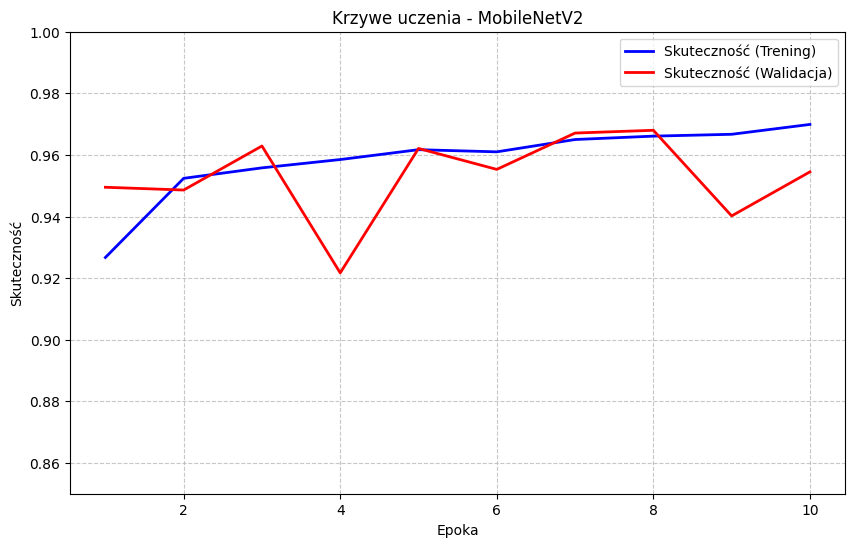

In [8]:
import matplotlib.pyplot as plt

# Procenty skopiowane z Twojego treningu MobileNetV2
epoki = range(1, 11)
skutecznosc_tren = [0.9267, 0.9524, 0.9558, 0.9585, 0.9617, 0.9610, 0.9650, 0.9661, 0.9667, 0.9699]
skutecznosc_walid = [0.9495, 0.9486, 0.9629, 0.9217, 0.9621, 0.9553, 0.9671, 0.9680, 0.9402, 0.9545]

plt.figure(figsize=(10, 6))
plt.plot(epoki, skutecznosc_tren, 'b-', label='Skuteczność (Trening)', linewidth=2)
plt.plot(epoki, skutecznosc_walid, 'r-', label='Skuteczność (Walidacja)', linewidth=2)

plt.title('Krzywe uczenia - MobileNetV2')
plt.xlabel('Epoka')
plt.ylabel('Skuteczność')
plt.ylim(0.85, 1.0) # Ustawiamy oś Y, żeby lepiej widzieć zmiany na górze
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Wybrałem zdjęcie z dysku: /home/mkaszycki/klasyfikator_galaktyk/Andromeda_Galaxy_(with_h-alpha) (1).jpg
Rozpoczynam analizę zapisanego modelu MobileNetV2...
------------------------------


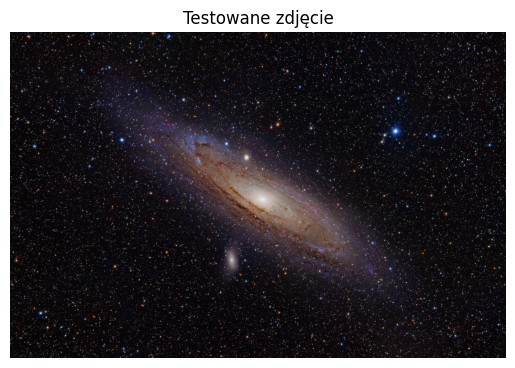

Werdykt...
Prawdopodobieństwo Eliptyczna: 17.30%
Prawdopodobieństwo Spiralna: 82.70%

=> Według mojego PRAWDZIWEGO modelu to na pewno: SPIRALNA!


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt

mobilenet = models.mobilenet_v2(weights=None)
wejscia_mobile = mobilenet.classifier[1].in_features
mobilenet.classifier[1] = nn.Linear(wejscia_mobile, 2)

urzadzenie = torch.device("cpu")
sciezka_wag = "najlepszy_MobileNetV2.pth"

mobilenet.load_state_dict(torch.load(sciezka_wag, map_location=urzadzenie))
mobilenet = mobilenet.to(urzadzenie)

transformacje_testowe = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

etykiety = {0: "Eliptyczna", 1: "Spiralna"}

def sprawdz_galaktyke(sciezka_do_zdjecia):
    img = Image.open(sciezka_do_zdjecia).convert("RGB")

    plt.imshow(img)
    plt.axis('off')
    plt.title("Testowane zdjęcie")
    plt.show()

    img_tensor = transformacje_testowe(img).unsqueeze(0).to(urzadzenie)

    mobilenet.eval()
    with torch.no_grad():
        wyniki = mobilenet(img_tensor)
        procenty = F.softmax(wyniki, dim=1)[0] * 100

    print("Werdykt...")
    print(f"Prawdopodobieństwo {etykiety[0]}: {procenty[0].item():.2f}%")
    print(f"Prawdopodobieństwo {etykiety[1]}: {procenty[1].item():.2f}%")

    zwyciezca = etykiety[torch.argmax(procenty).item()]
    print(f"\n=> Według mojego PRAWDZIWEGO modelu to na pewno: {zwyciezca.upper()}!")

testowa_sciezka = "/home/mkaszycki/klasyfikator_galaktyk/Andromeda_Galaxy_(with_h-alpha) (1).jpg"

print(f"Wybrałem zdjęcie z dysku: {testowa_sciezka}")
print("Rozpoczynam analizę zapisanego modelu MobileNetV2...")
print("-" * 30)
sprawdz_galaktyke(testowa_sciezka)

Wybrałem zdjęcie z dysku: /home/mkaszycki/klasyfikator_galaktyk/opo1038b.jpg
Rozpoczynam analizę zapisanego modelu ResNet50...
------------------------------


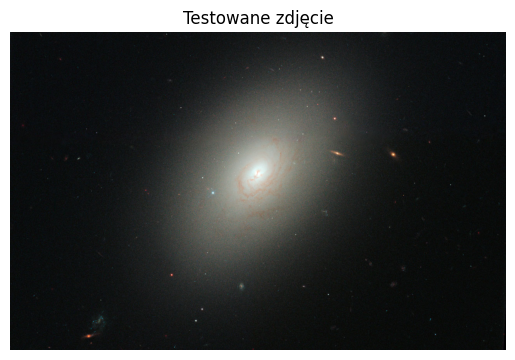

Werdykt...
Prawdopodobieństwo Eliptyczna: 83.33%
Prawdopodobieństwo Spiralna: 16.67%

=> Według mojego PRAWDZIWEGO modelu to na pewno: ELIPTYCZNA!


In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt

resnet = models.resnet50(weights=None)
wejscia_resnet = resnet.fc.in_features
resnet.fc = nn.Linear(wejscia_resnet, 2)

urzadzenie = torch.device("cpu")
sciezka_wag = "najlepszy_ResNet50.pth"

resnet.load_state_dict(torch.load(sciezka_wag, map_location=urzadzenie))
resnet = resnet.to(urzadzenie)

transformacje_testowe = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

etykiety = {0: "Eliptyczna", 1: "Spiralna"}

def sprawdz_galaktyke(sciezka_do_zdjecia):
    img = Image.open(sciezka_do_zdjecia).convert("RGB")

    plt.imshow(img)
    plt.axis('off')
    plt.title("Testowane zdjęcie")
    plt.show()

    img_tensor = transformacje_testowe(img).unsqueeze(0).to(urzadzenie)

    resnet.eval()
    with torch.no_grad():
        wyniki = resnet(img_tensor)
        procenty = F.softmax(wyniki, dim=1)[0] * 100

    print("Werdykt...")
    print(f"Prawdopodobieństwo {etykiety[0]}: {procenty[0].item():.2f}%")
    print(f"Prawdopodobieństwo {etykiety[1]}: {procenty[1].item():.2f}%")

    zwyciezca = etykiety[torch.argmax(procenty).item()]
    print(f"\n=> Według mojego PRAWDZIWEGO modelu to na pewno: {zwyciezca.upper()}!")

testowa_sciezka = "/home/mkaszycki/klasyfikator_galaktyk/opo1038b.jpg"

print(f"Wybrałem zdjęcie z dysku: {testowa_sciezka}")
print("Rozpoczynam analizę zapisanego modelu ResNet50...")
print("-" * 30)
sprawdz_galaktyke(testowa_sciezka)

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from PIL import Image
import time

urzadzenie = torch.device("cpu")


mobilenet = models.mobilenet_v2(weights=None)
mobilenet.classifier[1] = nn.Linear(mobilenet.classifier[1].in_features, 2)
mobilenet.load_state_dict(torch.load("najlepszy_MobileNetV2.pth", map_location=urzadzenie))
mobilenet = mobilenet.to(urzadzenie)
mobilenet.eval()


resnet = models.resnet50(weights=None)
resnet.fc = nn.Linear(resnet.fc.in_features, 2)
resnet.load_state_dict(torch.load("najlepszy_ResNet50.pth", map_location=urzadzenie))
resnet = resnet.to(urzadzenie)
resnet.eval()

# --- 3. SOCZEWKI (TRANSFORMACJE) ---
transformacje = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

etykiety = {0: "Eliptyczna", 1: "Spiralna"}

def porownaj_modele(sciezka_do_zdjecia):
    img = Image.open(sciezka_do_zdjecia).convert("RGB")
    img_tensor = transformacje(img).unsqueeze(0).to(urzadzenie)

    print(f"\n--- ZDJĘCIE: {sciezka_do_zdjecia} ---")
    
    with torch.no_grad():
        # Test MobileNetV2
        start = time.time()
        wyniki_mobile = mobilenet(img_tensor)
        czas_mobile = (time.time() - start) * 1000
        proc_mobile = F.softmax(wyniki_mobile, dim=1)[0] * 100
        zwyciezca_mobile = etykiety[torch.argmax(proc_mobile).item()]

        # Test ResNet50
        start = time.time()
        wyniki_resnet = resnet(img_tensor)
        czas_resnet = (time.time() - start) * 1000
        proc_resnet = F.softmax(wyniki_resnet, dim=1)[0] * 100
        zwyciezca_resnet = etykiety[torch.argmax(proc_resnet).item()]

    print("\n⚡ MOBILENETV2:")
    print(f"Werdykt: {zwyciezca_mobile.upper()} (Czas myślenia: {czas_mobile:.2f} ms)")
    
    print("\n🧠 RESNET50:")
    print(f"Werdykt: {zwyciezca_resnet.upper()} (Czas myślenia: {czas_resnet:.2f} ms)")


testowa_sciezka = "/home/mkaszycki/klasyfikator_galaktyk/hubble-examines-ellipt.jpg"  


porownaj_modele(testowa_sciezka)


--- ZDJĘCIE: /home/mkaszycki/klasyfikator_galaktyk/hubble-examines-ellipt.jpg ---

⚡ MOBILENETV2:
Werdykt: ELIPTYCZNA (Czas myślenia: 30.95 ms)

🧠 RESNET50:
Werdykt: ELIPTYCZNA (Czas myślenia: 193.23 ms)
